# Базовая модель Лотки–Вольтерры

Классическая система описывает циклическое взаимодействие популяций жертв
и хищников. Численно проверяются равновесие, фазовый сдвиг и первый интеграл.

Lotka–Volterra: alpha=0.1, beta=0.02, delta=0.01, gamma=0.3


Equilibrium: x*=30.0, y*=5.0
First peaks: prey t=33.7, predator t=40.6, lag=6.899999999999999
Invariant drift=1.2698360141172316e-9
Periods: theory=36.276, spectrum=40.02


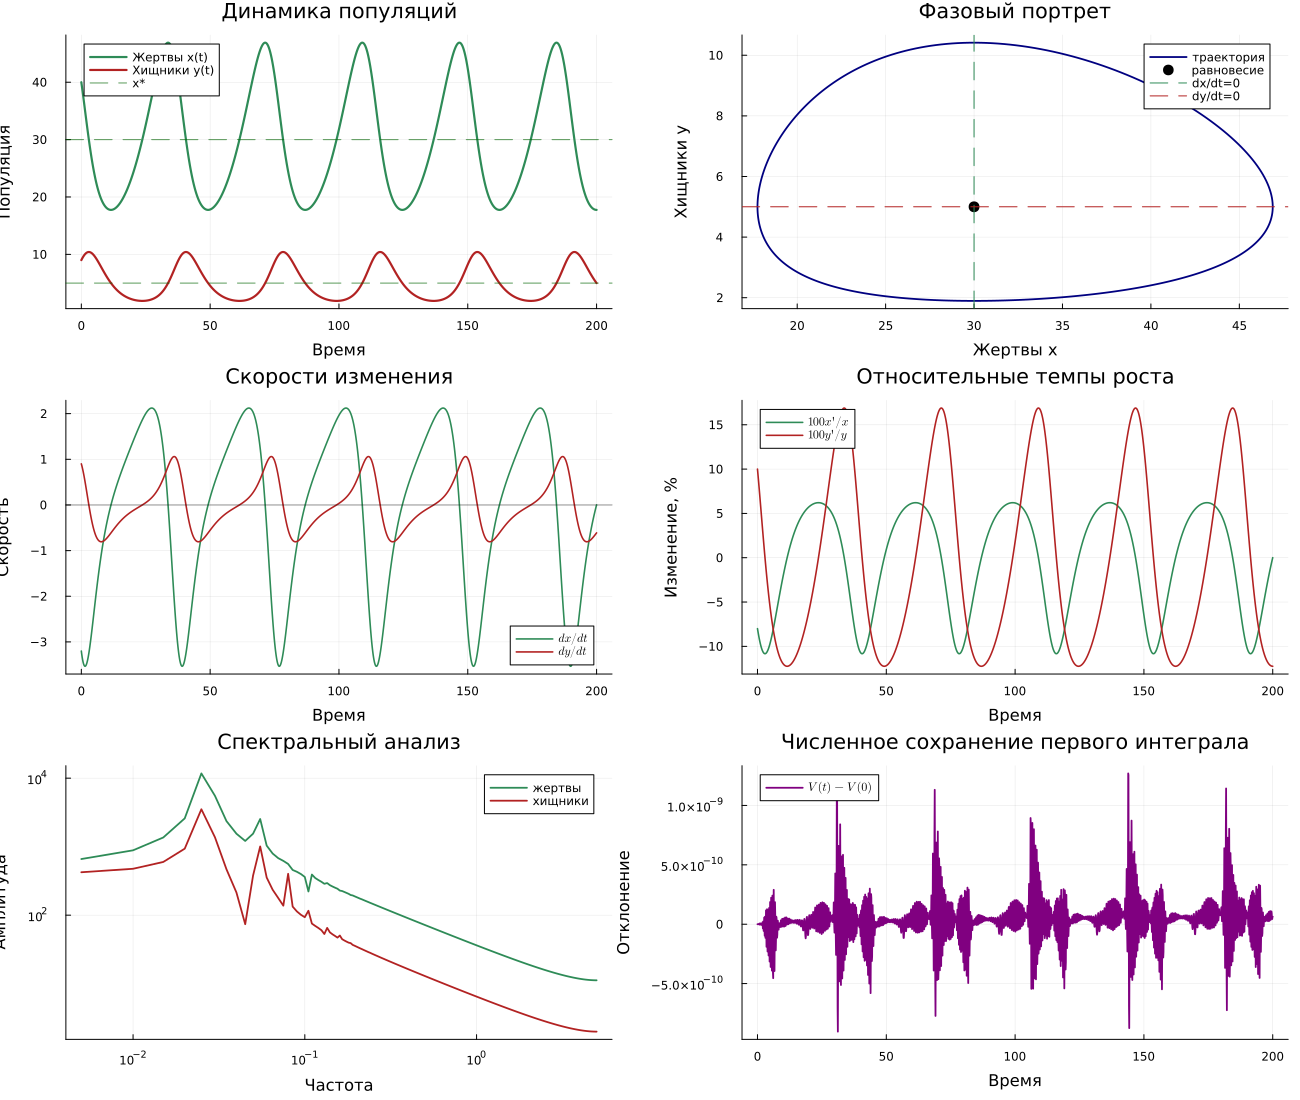

In [1]:
using DrWatson
@quickactivate "BasicModelsLab"
using BasicModelsLab.BasicModels
using CSV, DataFrames, FFTW, JLD2, LaTeXStrings, Plots, Statistics

script_name = "lv_ode"
mkpath(datadir(script_name))
mkpath(plotsdir(script_name))
gr()

p = [0.1, 0.02, 0.01, 0.3] # alpha, beta, delta, gamma
u0 = [40.0, 9.0]
tspan = (0.0, 200.0)
saveat = 0.1

solution = solve_lv(; u0, p, tspan, saveat)
lv = lv_dataframe(solution, p)
lv.invariant = invariant_lv(lv.prey, lv.predator, p)
x_star = p[4] / p[3]
y_star = p[1] / p[2]
theoretical_period = 2pi / sqrt(p[1] * p[4])
prey_peak = first_local_peak(lv.prey, lv.t)
predator_peak = first_local_peak(lv.predator, lv.t; start_index=prey_peak.index + 1)
phase_lag = predator_peak.time - prey_peak.time
invariant_drift = maximum(abs.(lv.invariant .- lv.invariant[1]))

CSV.write(datadir(script_name, "lv_trajectory.csv"), lv)
summary = DataFrame(
    metric=["x_star", "y_star", "period_theory", "prey_peak_time",
            "predator_peak_time", "phase_lag", "invariant_drift"],
    value=[x_star, y_star, theoretical_period, prey_peak.time,
           predator_peak.time, phase_lag, invariant_drift],
)
CSV.write(datadir(script_name, "lv_summary.csv"), summary)
@save datadir(script_name, "lv_solution.jld2") p u0 solution lv summary

println("Lotka–Volterra: alpha=$(p[1]), beta=$(p[2]), delta=$(p[3]), gamma=$(p[4])")
println("Equilibrium: x*=$(x_star), y*=$(y_star)")
println("First peaks: prey t=$(prey_peak.time), predator t=$(predator_peak.time), lag=$(phase_lag)")
println("Invariant drift=$(invariant_drift)")

dynamics = plot(lv.t, [lv.prey lv.predator];
    label=["Жертвы x(t)" "Хищники y(t)"], xlabel="Время",
    ylabel="Популяция", title="Динамика популяций", lw=2.2,
    color=[:seagreen :firebrick], size=(900, 520))
hline!(dynamics, [x_star, y_star]; label=["x*" "y*"],
       color=[:darkgreen :darkred], ls=:dash, alpha=.65)

phase = plot(lv.prey, lv.predator; label="траектория", xlabel="Жертвы x",
    ylabel="Хищники y", title="Фазовый портрет", color=:navy, lw=1.8,
    size=(820, 560))
scatter!(phase, [x_star], [y_star]; label="равновесие", color=:black, ms=6)
vline!(phase, [x_star]; label="dx/dt=0", color=:seagreen, ls=:dash)
hline!(phase, [y_star]; label="dy/dt=0", color=:firebrick, ls=:dash)

derivatives = plot(lv.t, [lv.dprey_dt lv.dpredator_dt];
    label=[L"dx/dt" L"dy/dt"], xlabel="Время", ylabel="Скорость",
    title="Скорости изменения", color=[:seagreen :firebrick], lw=1.6,
    size=(900, 440))
hline!(derivatives, [0.0]; label="", color=:black, alpha=.4)

relative = plot(lv.t, [lv.prey_pct_change lv.predator_pct_change];
    label=[L"100x'/x" L"100y'/y"], xlabel="Время", ylabel="Изменение, %",
    title="Относительные темпы роста", color=[:seagreen :firebrick],
    lw=1.6, size=(900, 440))

function positive_spectrum(values, step)
    centered = values .- mean(values)
    amplitude = abs.(rfft(centered))
    frequency = rfftfreq(length(centered), inv(step))
    return frequency[2:end], amplitude[2:end]
end

frequency, prey_spectrum = positive_spectrum(lv.prey, saveat)
_, predator_spectrum = positive_spectrum(lv.predator, saveat)
dominant_index = argmax(prey_spectrum)
observed_period = 1 / frequency[dominant_index]
spectrum = plot(frequency, [prey_spectrum predator_spectrum];
    label=["жертвы" "хищники"], xlabel="Частота", ylabel="Амплитуда",
    title="Спектральный анализ", xscale=:log10, yscale=:log10,
    color=[:seagreen :firebrick], lw=1.8, size=(900, 440))

invariant_plot = plot(lv.t, lv.invariant .- lv.invariant[1];
    label=L"V(t)-V(0)", xlabel="Время", ylabel="Отклонение",
    title="Численное сохранение первого интеграла", color=:purple,
    lw=1.8, size=(900, 440))

panel = plot(dynamics, phase, derivatives, relative, spectrum, invariant_plot;
             layout=(3, 2), size=(1300, 1100))
for (plot_object, filename) in [
    (dynamics, "lv_dynamics.png"), (phase, "lv_phase_portrait.png"),
    (derivatives, "lv_derivatives.png"), (relative, "lv_relative_changes.png"),
    (spectrum, "lv_spectrum.png"), (invariant_plot, "lv_invariant.png"),
    (panel, "lv_panel.png")]
    savefig(plot_object, plotsdir(script_name, filename))
end

println("Periods: theory=$(round(theoretical_period, digits=3)), spectrum=$(round(observed_period, digits=3))")
display(panel)